# This code is used to import the model and run the model.

In [78]:
%pip install torch==2.6.0
%pip install torchvision==0.21.0
%pip install numpy
%pip install matplotlib
%pip install tdqm
%pip install numpy==1.24.1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.24.1.tar.gz (10.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "/home/ubuntu/persistent/144Venv/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/home/ubuntu/persistent/144Venv/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["ret

In [ ]:
# Imports
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# Check is there any hardware acceleration

In [82]:
# https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

cuda


# Load the model
* https://pytorch.org/tutorials/beginner/saving_loading_models.html

In [ ]:

# Define Custom Classification Head for ViT
class ViTHead(nn.Module):
    def __init__(self, in_features=768, num_classes=100):  # Adjust `in_features` to match ViT output
        super(ViTHead, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

# Load pretrained ViT model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)

# Extract the number of input features for the classification head
in_features = base_model.heads.head.in_features  

# Replace the classification head with a custom one
base_model.heads.head = ViTHead(in_features=in_features, num_classes=100).to(device)

# Verify Model Architecture
print(base_model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

# Load weights

In [ ]:
# Change FILE_PATH to the weights path
FILE_PATH: str = "./weights/20250311_052834.pth"

base_model.load_state_dict(torch.load(FILE_PATH, weights_only=True,map_location=torch.device(device)))

<All keys matched successfully>

# Transform image

In [85]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# Load test 

In [86]:
TEST_DIR_PATH: str = "./test"

dataset: datasets.ImageFolder = datasets.ImageFolder(TEST_DIR_PATH, transform=transform)
loader: DataLoader = DataLoader(dataset, shuffle=False)
filepaths = [sample[0] for sample in dataset.samples]

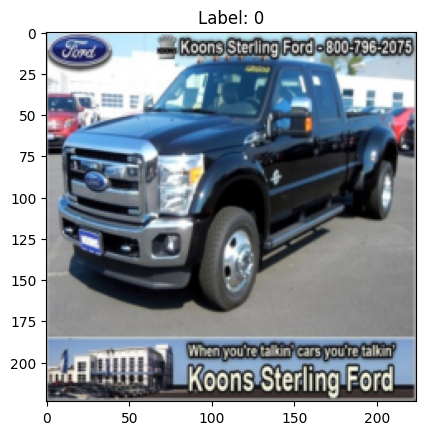

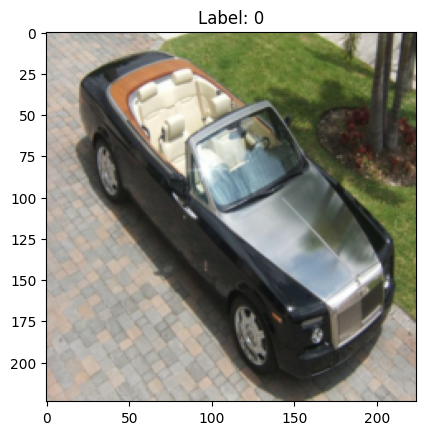

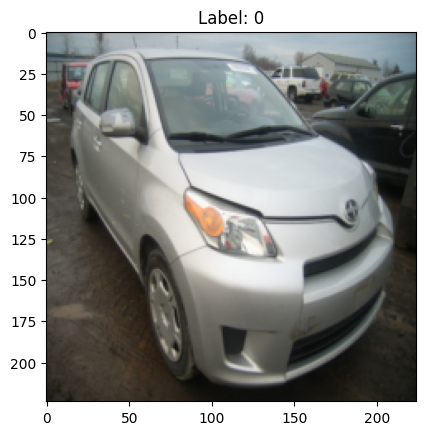

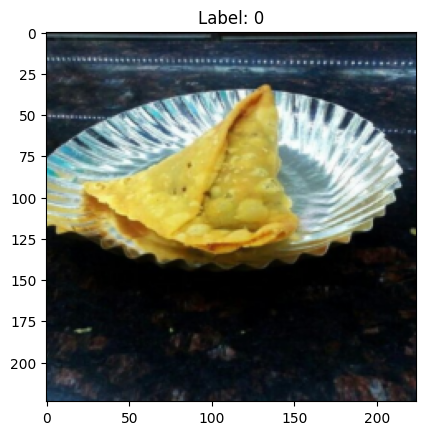

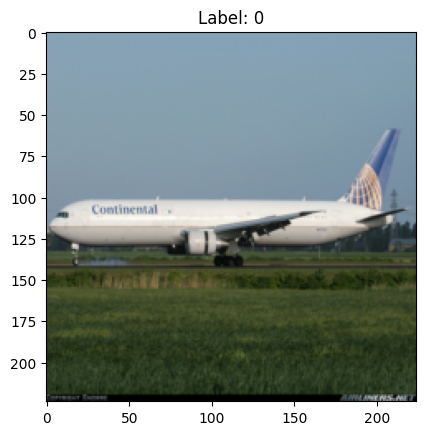

In [ ]:
def display_images(num_images):
    for i, (image, label) in enumerate(loader):
        if i >= num_images:
            break
        plt.imshow(image[0].permute(1, 2, 0))
        plt.title(f"Label: {label[0]}")
        plt.show()

display_images(5)

In [ ]:
RESULT_CSV_PATH: str = "pumping_lemma_proof.csv"

with open(RESULT_CSV_PATH, 'w') as f:
    f.write("ID,Label\n")

i: int = 0
store_result: dict = {}
for data in loader:
    image, label = data
    image, label = image.to(device=device), label.to(device=device)
    with torch.no_grad():
        output = base_model(image)

    _, predicted = torch.max(output.data, 1)

    predicted: int = predicted.to('cpu').numpy()[0]
    store_result[os.path.basename(filepaths[i])] = predicted
    i += 1

print(store_result)


for k in range(1000):
    with open(RESULT_CSV_PATH, 'a') as f:
        f.write(f"{k}.jpg,{store_result[str(k)+".jpg"]}\n")

{'0.jpg': np.int64(96), '1.jpg': np.int64(81), '10.jpg': np.int64(25), '100.jpg': np.int64(48), '101.jpg': np.int64(2), '102.jpg': np.int64(2), '103.jpg': np.int64(32), '104.jpg': np.int64(29), '105.jpg': np.int64(1), '106.jpg': np.int64(70), '107.jpg': np.int64(84), '108.jpg': np.int64(79), '109.jpg': np.int64(5), '11.jpg': np.int64(13), '110.jpg': np.int64(6), '111.jpg': np.int64(25), '112.jpg': np.int64(0), '113.jpg': np.int64(87), '114.jpg': np.int64(43), '115.jpg': np.int64(3), '116.jpg': np.int64(25), '117.jpg': np.int64(87), '118.jpg': np.int64(25), '119.jpg': np.int64(14), '12.jpg': np.int64(28), '120.jpg': np.int64(31), '121.jpg': np.int64(35), '122.jpg': np.int64(28), '123.jpg': np.int64(86), '124.jpg': np.int64(23), '125.jpg': np.int64(40), '126.jpg': np.int64(81), '127.jpg': np.int64(4), '128.jpg': np.int64(47), '129.jpg': np.int64(92), '13.jpg': np.int64(20), '130.jpg': np.int64(7), '131.jpg': np.int64(9), '132.jpg': np.int64(2), '133.jpg': np.int64(47), '134.jpg': np.int6